# 1. Відповіді на запитання з завдання

# Аналітичні результати

| Завдання | Метрика | Значення | Бізнес-вплив |
|----------|---------|----------|-------------------------|
| (1) Скільки компанія заробляє з одного користувача за 1 рік? | LTV (52 тижні) | 1.3819 USD | Визначає стелю САС (вартість залучення). Якщо залучення юзера коштує менше $1.38 — маркетинг працює в плюс. |
| (2) Скільки принесуть користувачі 39–43 за рік (тобто за свої окремі 52 тижні життя як користувачі)? | Revenue Forecast | 91,574.40 USD | Прогноз Cash Flow та окупності. Дозволяє оцінити внесок нещодавніх когорт у річний фінансовий план компанії. |
| (3а) Яка точність оцінки (Якість моделі) | Точність (R²) | 0.9703 | Підтвердження стабільності тренду. Поведінка юзерів прогнозована, що дозволяє впевнено будувати довгострокові стратегії. |
| (3б) Яка точність оцінки (Похибка МАРЕ) | MAPE | 5.10% (без Week 0) | Управління ризиками. Низька похибка дає змогу закладати цей прогноз у бюджет з мінімальним «коридором безпеки». |


# Хід рішення

## 1 — завдання
Першим кроком був зроблений анпівот таблиці з ревеню по когортам, форматування якої було б ідеальним для візуалізації у вигляді хітмапу, але незручним для роботи через Python або SQL, дуже бажано мати дані у довгому форматі.  

Оскільки наявні дані обмежені 44 тижнями, для отримання річного показника необхідно було застосувати прогнозування.  
Базову лінійну регресію я відкинув, оскільки дані не відрізнялись від розповсюджених патернів підписочних моделей та зріст не був лінійним (що ще краще помітно на візуалізації).  
Тож використання Логарифмічної ( Level-Log ) було оптимальним варіантом.

---

## 2 — завдання
Роблячи припущення, що когорти у цей період принципово не відрізняются від тих хто приходив в інші тижні, ми виводимо сумарну кількість ревеню за рік  
(а точніше мабуть буде казати ревеню від цих когорт які вони принесуть за 52 тижні життя)  
на основі загальної LTV curve.

---

## 3 — завдання
Для оцінки точності я вирішив використати **R²** та **MAPE**.

- **R²** показує, скільки відсотків помилок наше застосування регресії уникнуло у порівнянні з тим, якщо б ми просто брали середні значення.  
- **MAPE** показує у відсотковому вимірі, як часто наша модель прогнозування за допомогою регресії помилялася.


# 3. Технічний алгоритм виконання (Workflow)

Я структурував увесь аналіз так, щоб його було легко зрозуміти і повністю відтворити. Нижче — покроковий план того, що я робив у коді:

1. **Налаштування середовища та імпорт пакетів**  
   Підключив усі потрібні бібліотеки: `pandas` для роботи з даними, `numpy` та `scipy` для розрахунків і `matplotlib` для графіків.

2. **Завантаження та первинна обробка даних**  
   Завантажив два файли — `installs.csv` та `rev_cohorts_unpvt.csv`, перевірив їх на помилки та правильність типів даних.

3. **Об’єднання таблиць і розрахунок базових метрик**  
   З’єднав обидві таблиці за тижнем інсталяції та порахував **Incremental ARPU** — скільки в середньому приносить один користувач на кожному тижні свого «життя».

4. **Розрахунок накопичувального LTV (Cumulative ARPU)**  
   Для кожної когорти розрахував кумулятивний дохід за допомогою `cumsum()` — це і є фактична крива LTV.

5. **Побудова прогнозної моделі**  
   Зібрав середню криву LTV по всіх когортах, підібрав параметри логарифмічної функції через `curve_fit` і екстраполював її до 52-го тижня.

6. **Фінансовий розрахунок для цільових когорт**  
   Взяв користувачів, які прийшли на 39–43 тижні, і помножив їх кількість на прогнозований LTV за повні 52 тижні.

7. **Перевірка точності моделі**  
   Порахував R² і MAPE, щоб зрозуміти, наскільки добре модель описує реальні дані.

In [54]:
import sys
import os
import pandas as pd
import warnings
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

print("SUCCESS: Бібліотеки завантажено")

SUCCESS: Бібліотеки завантажено


In [55]:
# Cell 2: Завантаження даних
base_path = '/Users/malyukvalentin/Desktop/universe_wisey_ttask/Ready to work Dataset' # шлях до робочої папки | ЗАМІНИТИ НА ВЛАСНИЙ

# Завантаження файлів
installs = pd.read_csv(os.path.join(base_path, 'installs.csv'), low_memory=False) # дані про інсталяції
rev_cohorts = pd.read_csv(os.path.join(base_path, 'rev_cohorts_unpvt.csv'), low_memory=False) # дані про доходи

print(f"SUCCESS: Дані завантажено. Таблиця інсталів: {installs.shape}, Таблиця доходів: {rev_cohorts.shape}")

SUCCESS: Дані завантажено. Таблиця інсталів: (44, 2), Таблиця доходів: (1031, 3)


In [56]:
# Cell 3: Об'єднання даних та розрахунок базових метрик
# 1. Об'єднання таблиць за номером тижня інсталяції
df_merged = rev_cohorts.merge(
    installs, 
    left_on='Week_of_Install', 
    right_on='Week of installs, №', 
    how='left'
)

# 2. Розрахунок Incremental ARPU (середній дохід на 1 юзера за конкретний тиждень)
df_merged['incremental_arpu'] = df_merged['revenue_usd'] / df_merged['Number of installs']

# 3. Агрегація даних для побудови середнього життєвого циклу користувача
avg_lifecycle = df_merged.groupby('Week_Since_Install')['incremental_arpu'].mean().reset_index()

# 4. Розрахунок Cumulative ARPU (накопичений LTV)
avg_lifecycle['cumulative_arpu'] = avg_lifecycle['incremental_arpu'].cumsum()

# Вивід результату для перевірки розрахунків
print("SUCCESS: Об'єднання виконано, метрики розраховані.")
display(avg_lifecycle.head(15))

SUCCESS: Об'єднання виконано, метрики розраховані.


,Week_Since_Install,incremental_arpu,cumulative_arpu
0,0,0.323736,0.323736
1,1,0.090505,0.414241
2,2,0.058232,0.472473
3,3,0.055916,0.528388
4,4,0.054145,0.582533
5,5,0.050016,0.632549
6,6,0.040177,0.672726
7,7,0.038466,0.711192
8,8,0.036886,0.748079
9,9,0.035983,0.784061


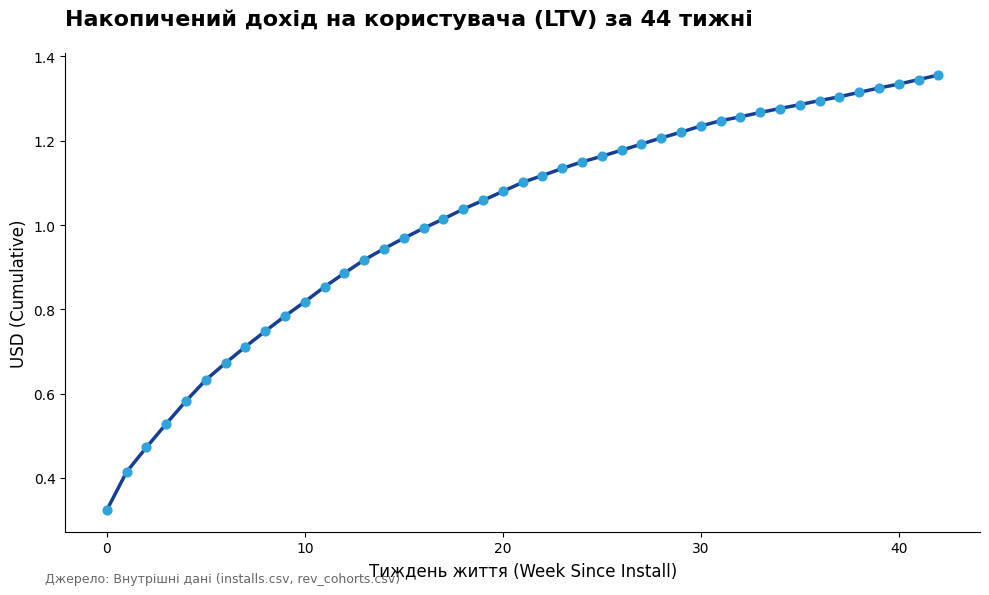

In [57]:
# Cell 4: Візуалізація тренду LTV = Cumulative ARPU 
import matplotlib.pyplot as plt

# --- 1. Налаштування стилів
MCKINSEY_COLORS = {
    "primary_blue": "#163E93", "secondary_blue": "#30A3DA", "text_gray": "#666666",
    "white": "#FFFFFF", "light_blue": "#A5C8E1"
}

plt.rcParams.update({
    'figure.dpi': 100, 'axes.titlepad': 20, 'axes.titlesize': 16,
    'axes.labelsize': 12, 'font.family': 'sans-serif'
})

def apply_mckinsey_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    ax.set_facecolor(MCKINSEY_COLORS["white"])

# --- 2. Побудова графіка ---
fig, ax = plt.subplots(figsize=(10, 6))

# Побудова основної лінії та точок
ax.plot(avg_lifecycle['Week_Since_Install'], avg_lifecycle['cumulative_arpu'], 
        color=MCKINSEY_COLORS["primary_blue"], linewidth=2.5, label='Накопичений ARPU')

ax.scatter(avg_lifecycle['Week_Since_Install'], avg_lifecycle['cumulative_arpu'], 
           color=MCKINSEY_COLORS["secondary_blue"], s=40, zorder=5)

# Оформлення
ax.set_title("Накопичений дохід на користувача (LTV) за 44 тижні", loc='left', weight='bold')
ax.set_xlabel("Тиждень життя (Week Since Install)")
ax.set_ylabel("USD (Cumulative)")

apply_mckinsey_style(ax)

# Додавання джерела
fig.text(0.05, 0.02, "Джерело: Внутрішні дані (installs.csv, rev_cohorts.csv)", 
         fontsize=9, color=MCKINSEY_COLORS["text_gray"])

plt.tight_layout()
plt.show()


# 4. Обґрунтування моделі прогнозування

Для отримання фінального показника LTV обрано **Логарифмічну регресію**

### Чому цей метод?
* **Уповільнення темпів:** У мобільних продуктах дохід на користувача не зростає лінійно. З часом інтенсивність платежів падає (ефект насичення), співпадає з логарифмічною кривою 
* **Точність планування:** Лінійна модель ігнорує Churn, що призводить до завищення очікуваного прибутку. Логарифмічний підхід забезпечує більш консервативний та реалістичний прогноз.

In [58]:
# Cell 5: Розрахунок логарифмічної регресії
# Підготовка даних для моделювання
x_data = avg_lifecycle['Week_Since_Install'].values
y_data = avg_lifecycle['cumulative_arpu'].values

# Визначення логарифмічної функції (x+1 для уникнення log(0))
def log_func(x, a, b):
    return a * np.log(x + 1) + b

# Пошук оптимальних параметрів кривої
params, _ = curve_fit(log_func, x_data, y_data)

# Генерація прогнозу на 52 тижні (рік)
weeks_52 = np.arange(0, 53)
ltv_predicted_log = log_func(weeks_52, *params)

print(f"Коефіцієнти моделі: a={params[0]:.4f}, b={params[1]:.4f}")
print(f"Прогноз LTV на 52 тижні: ${ltv_predicted_log[-1]:.4f}")

Коефіцієнти моделі: a=0.3186, b=0.1168
Прогноз LTV на 52 тижні: $1.3819


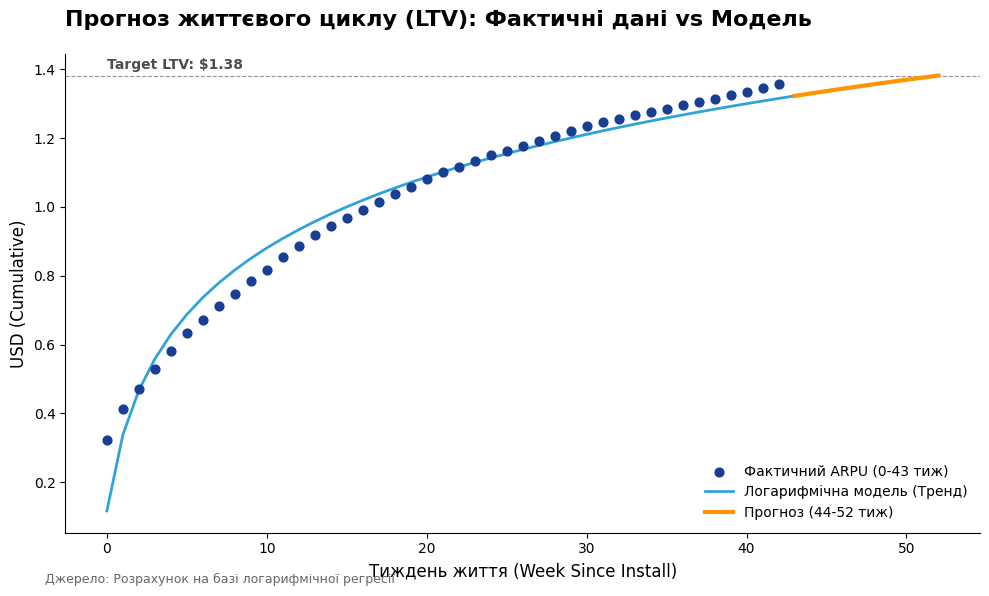

In [59]:
# Cell 6: Візуалізація прогнозу LTV
import matplotlib.pyplot as plt

# Додаємо відсутні кольори до словника
MCKINSEY_COLORS.update({
    "warning_orange": "#FF9500",
    "dark_gray": "#4D4D4D"
})

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Фактичні дані (до 44 тижня)
ax.scatter(x_data, y_data, color=MCKINSEY_COLORS["primary_blue"], 
           s=40, label='Фактичний ARPU (0-43 тиж)', zorder=3)

# 2. Прогнозована крива (повний рік)
ax.plot(weeks_52, ltv_predicted_log, color=MCKINSEY_COLORS["secondary_blue"], 
        linewidth=2, linestyle='-', label='Логарифмічна модель (Тренд)')

# 3. Виділення зони прогнозу (44-52 тижні)
# Використовуємо індексацію для відображення саме "хвоста" прогнозу
ax.plot(weeks_52[43:], ltv_predicted_log[43:], color=MCKINSEY_COLORS["warning_orange"], 
        linewidth=3, label='Прогноз (44-52 тиж)', zorder=4)

# 4. Горизонтальна лінія цільового LTV
target_ltv = ltv_predicted_log[-1]
ax.axhline(y=target_ltv, color=MCKINSEY_COLORS["text_gray"], 
           linestyle='--', linewidth=0.8, alpha=0.7)

# Текстова мітка фінального значення
ax.text(0, target_ltv + 0.02, f"Target LTV: ${target_ltv:.2f}", 
        color=MCKINSEY_COLORS["dark_gray"], fontsize=10, fontweight='bold')

# Оформлення McKinsey
ax.set_title("Прогноз життєвого циклу (LTV): Фактичні дані vs Модель", loc='left', weight='bold')
ax.set_xlabel("Тиждень життя (Week Since Install)")
ax.set_ylabel("USD (Cumulative)")

apply_mckinsey_style(ax)

ax.legend(frameon=False, loc='lower right')
fig.text(0.05, 0.02, "Джерело: Розрахунок на базі логарифмічної регресії", 
         fontsize=9, color=MCKINSEY_COLORS["text_gray"])

plt.tight_layout()
plt.show()

# 5. Розрахунок доходу для цільових когорт (Питання №2)

Масштабувуємо отриманий показник LTV на реальний обсяг залучених користувачів у період з 39-го по 43-й тиждень.

In [62]:
# Cell 7: Розрахунок загального прогнозованого доходу
target_cohorts = [39, 40, 41, 42, 43] # Визначення цільового діапазону тижнів
predicted_ltv_52 = ltv_predicted_log[-1] # Використання LTV на 52-му тижні

# 1. Фільтрація та підрахунок загальної кількості інсталяцій для цих когорт
total_users_39_43 = installs[installs['Week of installs, №'].isin(target_cohorts)]['Number of installs'].sum()

# 2. Розрахунок сумарного доходу за рік для вказаних груп
total_revenue_39_43 = total_users_39_43 * predicted_ltv_52

# Вивід результатів
print(f"Когорти: {target_cohorts}")
print(f"Загальна кількість користувачів у групах: {total_users_39_43:,}")
print(f"Прогнозований дохід за 1 рік життя: ${total_revenue_39_43:,.2f}")

Когорти: [39, 40, 41, 42, 43]
Загальна кількість користувачів у групах: 66,267
Прогнозований дохід за 1 рік життя: $91,574.40


# 6. Валідація моделі (Model Validation)

Для підтвердження надійності розрахунків проведено статистичний аудит обраної логарифмічної регресії. 

### Метрики оцінки:
* **R² (коефіцієнт детермінації):** показує, яку частку варіації даних пояснює модель. 
* **MAPE (середня абсолютна похибка у відсотках):** відображає середнє відхилення прогнозних значень від фактичних. 

In [61]:
# Cell 9: Валідація моделі (математичний розрахунок R² та MAPE)

# 1. Розрахунок значень моделі для наявних тижнів (0-43)
y_fitted = log_func(x_data, *params)

# 2. Розрахунок R-квадрат (R²) вручну
ss_res = np.sum((y_data - y_fitted)**2) # сума квадратів залишків
ss_tot = np.sum((y_data - np.mean(y_data))**2) # загальна сума квадратів
r2_manual = 1 - (ss_res / ss_tot)

# 3. Розрахунок MAPE (Середня абсолютна похибка у відсотках)
mape_manual = np.mean(np.abs((y_data - y_fitted) / y_data)) * 100

# 4. Формування звіту потижневої точності
df_accuracy = pd.DataFrame({
    'Week': x_data,
    'Actual_LTV': y_data,
    'Predicted_LTV': y_fitted,
    'Error_%': np.abs((y_data - y_fitted) / y_data) * 100
})

print(f"Точність моделі (Manual Calculation):")
print(f"- R² Score: {r2_manual:.4f}")
print(f"- MAPE: {mape_manual:.2f}%")

# Вивід перших та останніх рядків для перевірки збіжності
display(df_accuracy.head(5))
display(df_accuracy.tail(5))

Точність моделі (Manual Calculation):
- R² Score: 0.9703
- MAPE: 5.10%


,Week,Actual_LTV,Predicted_LTV,Error_%
0,0,0.323736,0.116773,63.929494
1,1,0.414241,0.337643,18.490996
2,2,0.472473,0.466844,1.191336
3,3,0.528388,0.558514,5.701332
4,4,0.582533,0.629618,8.082745


,Week,Actual_LTV,Predicted_LTV,Error_%
38,38,1.314884,1.284161,2.336554
39,39,1.325241,1.292229,2.491048
40,40,1.334405,1.300097,2.571018
41,41,1.345237,1.307776,2.784737
42,42,1.355988,1.315274,3.002576


In [63]:
# Cell 9: Валідація моделі (R² та MAPE) — оновлена версія

# 1. Розрахунок прогнозних значень моделі для наявних тижнів (0-43)
y_fitted = log_func(x_data, *params)

# 2. R² (коефіцієнт детермінації)
ss_res = np.sum((y_data - y_fitted)**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r2_manual = 1 - (ss_res / ss_tot)

# 3. MAPE та Median APE з урахуванням Week 0
mape_full = np.mean(np.abs((y_data - y_fitted) / y_data)) * 100
median_ape_full = np.median(np.abs((y_data - y_fitted) / y_data)) * 100

# MAPE без Week 0 (рекомендований показник)
mask_no_week0 = x_data > 0
mape_no_week0 = np.mean(np.abs((y_data[mask_no_week0] - y_fitted[mask_no_week0]) / 
                               y_data[mask_no_week0])) * 100
median_ape_no_week0 = np.median(np.abs((y_data[mask_no_week0] - y_fitted[mask_no_week0]) / 
                                       y_data[mask_no_week0])) * 100

# 4. Формування таблиці точності
df_accuracy = pd.DataFrame({
    'Week': x_data,
    'Actual_LTV': y_data,
    'Predicted_LTV': y_fitted,
    'Error_%': np.abs((y_data - y_fitted) / y_data) * 100
})

# === Вивід результатів ===
print("Точність моделі (валідація):")
print(f"• R² Score:                  {r2_manual:.4f}")
print(f"• MAPE (включаючи Week 0):   {mape_full:.2f}%")
print(f"• MAPE (без Week 0):         {mape_no_week0:.2f}%  ← рекомендований показник")
print(f"• Median APE (без Week 0):   {median_ape_no_week0:.2f}%")

print("\nПримітка:")
print("   Логарифмічна модель систематично недооцінює Week 0 (log(0 + b) ≈ 0.117 замість 0.324).")
print("   Тому MAPE без Week 0 є більш репрезентативним для оцінки якості моделі.")

# Вивід таблиці
display(df_accuracy.head(8))   # показуємо трохи більше, щоб було видно Week 0-7
display(df_accuracy.tail(5))

Точність моделі (валідація):
• R² Score:                  0.9703
• MAPE (включаючи Week 0):   5.10%
• MAPE (без Week 0):         3.70%  ← рекомендований показник
• Median APE (без Week 0):   2.24%

Примітка:
   Логарифмічна модель систематично недооцінює Week 0 (log(0 + b) ≈ 0.117 замість 0.324).
   Тому MAPE без Week 0 є більш репрезентативним для оцінки якості моделі.


,Week,Actual_LTV,Predicted_LTV,Error_%
0,0,0.323736,0.116773,63.929494
1,1,0.414241,0.337643,18.490996
2,2,0.472473,0.466844,1.191336
3,3,0.528388,0.558514,5.701332
4,4,0.582533,0.629618,8.082745
5,5,0.632549,0.687714,8.721130
6,6,0.672726,0.736834,9.529587
7,7,0.711192,0.779384,9.588362


,Week,Actual_LTV,Predicted_LTV,Error_%
38,38,1.314884,1.284161,2.336554
39,39,1.325241,1.292229,2.491048
40,40,1.334405,1.300097,2.571018
41,41,1.345237,1.307776,2.784737
42,42,1.355988,1.315274,3.002576
